In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting theme for professional visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load the raw dataset
df = pd.read_csv('../data/raw/data.csv')

# View data dimensions and quick info summary
print(f"Dataset Shape: {df.shape}\n")
print("Data Types and Missing Values Summary:")
df.info()

Dataset Shape: (95662, 16)

Data Types and Missing Values Summary:
<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrateg

In [2]:
# Inspect first 5 rows
print("First 5 rows of data:")
display(df.head())

# Check how unique the categorical variables are
print("\nUnique value counts per categorical column:")
categorical_cols = ['CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'PricingStrategy']
for col in categorical_cols:
    print(f" - {col}: {df[col].nunique()} unique categories")

First 5 rows of data:


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0



Unique value counts per categorical column:
 - CurrencyCode: 1 unique categories
 - CountryCode: 1 unique categories
 - ProviderId: 6 unique categories
 - ProductId: 23 unique categories
 - ProductCategory: 9 unique categories
 - ChannelId: 4 unique categories
 - PricingStrategy: 4 unique categories


In [3]:
print("Numerical Fields Distribution Summary:")
display(df[['Amount', 'Value', 'PricingStrategy', 'FraudResult']].describe())

Numerical Fields Distribution Summary:


,Amount,Value,PricingStrategy,FraudResult
count,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,6.717846e+03,9.900584e+03,2.255974,0.002018
std,1.233068e+05,1.231221e+05,0.732924,0.044872
min,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,2.800000e+03,5.000000e+03,2.000000,0.000000
max,9.880000e+06,9.880000e+06,4.000000,1.000000


In [4]:
print("Numerical Fields Distribution Summary:")
display(df[['Amount', 'Value', 'PricingStrategy', 'FraudResult']].describe())

Numerical Fields Distribution Summary:


,Amount,Value,PricingStrategy,FraudResult
count,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,6.717846e+03,9.900584e+03,2.255974,0.002018
std,1.233068e+05,1.231221e+05,0.732924,0.044872
min,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,2.800000e+03,5.000000e+03,2.000000,0.000000
max,9.880000e+06,9.880000e+06,4.000000,1.000000


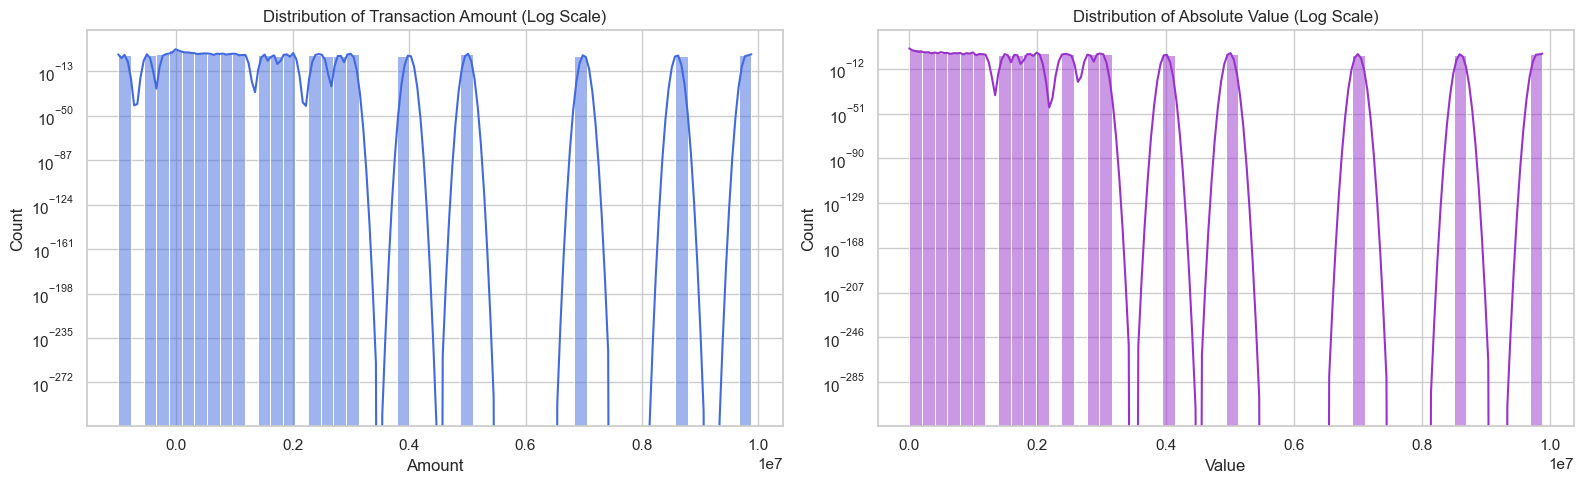

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot transaction Amount
sns.histplot(df['Amount'], bins=50, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribution of Transaction Amount (Log Scale)')
axes[0].set_yscale('log')
axes[0].set_xlabel('Amount')

# Plot absolute Value
sns.histplot(df['Value'], bins=50, kde=True, ax=axes[1], color='darkorchid')
axes[1].set_title('Distribution of Absolute Value (Log Scale)')
axes[1].set_yscale('log')
axes[1].set_xlabel('Value')

plt.tight_layout()
plt.show()

C:\Users\abbadal\AppData\Local\Temp\ipykernel_35420\663661661.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='ProductCategory', order=df['ProductCategory'].value_counts().index, ax=axes[0], palette='viridis')
C:\Users\abbadal\AppData\Local\Temp\ipykernel_35420\663661661.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='ChannelId', order=df['ChannelId'].value_counts().index, ax=axes[1], palette='flare')


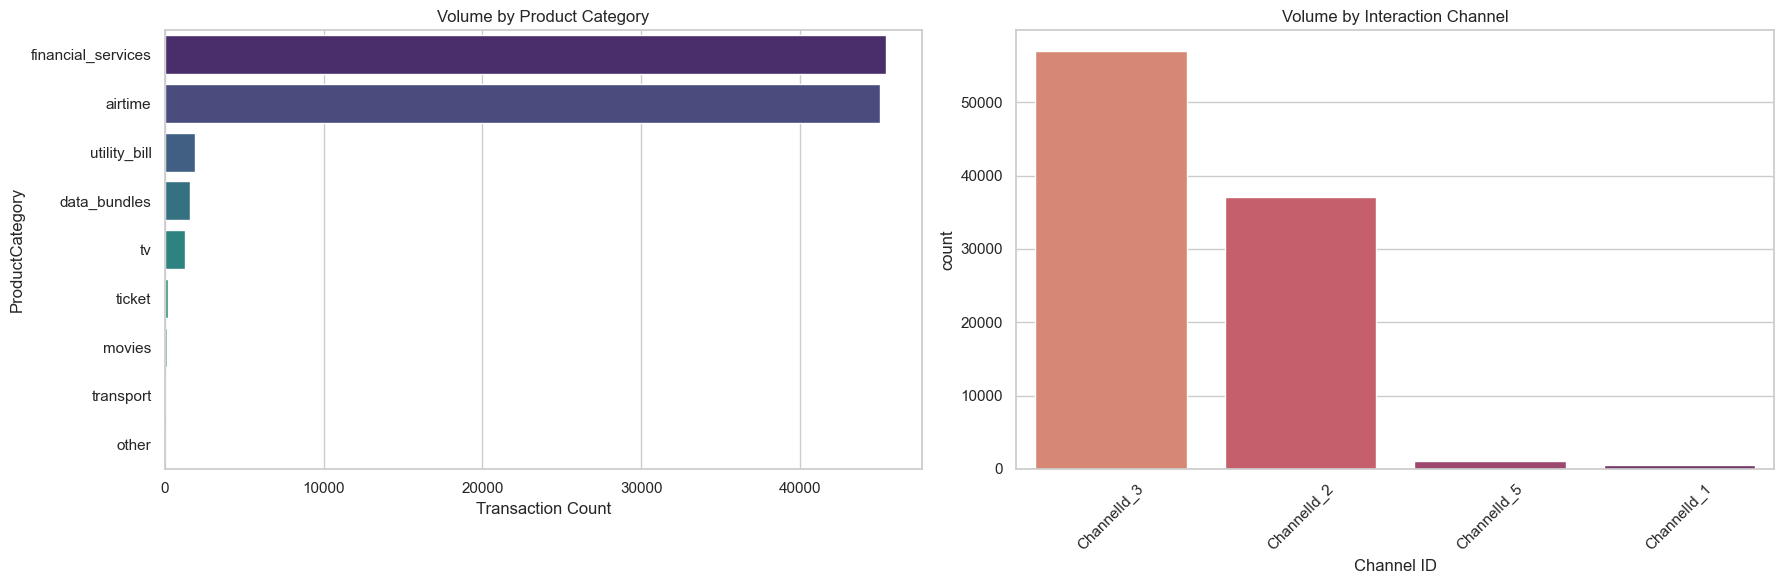

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Transaction counts across Product Categories
sns.countplot(data=df, y='ProductCategory', order=df['ProductCategory'].value_counts().index, ax=axes[0], palette='viridis')
axes[0].set_title('Volume by Product Category')
axes[0].set_xlabel('Transaction Count')

# Transaction counts across Channels
sns.countplot(data=df, x='ChannelId', order=df['ChannelId'].value_counts().index, ax=axes[1], palette='flare')
axes[1].set_title('Volume by Interaction Channel')
axes[1].set_xlabel('Channel ID')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

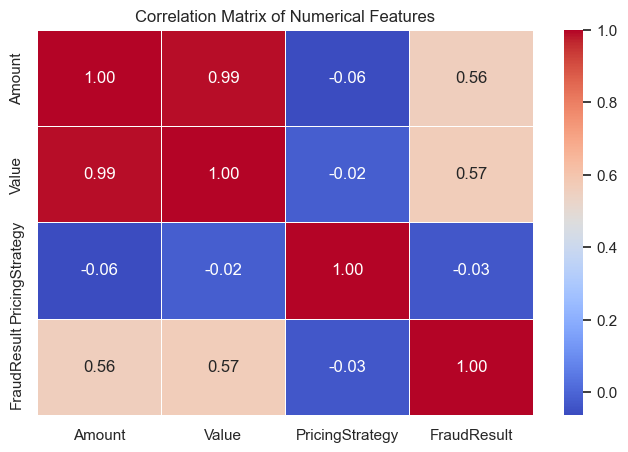

In [7]:
plt.figure(figsize=(8, 5))
correlation_matrix = df[['Amount', 'Value', 'PricingStrategy', 'FraudResult']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

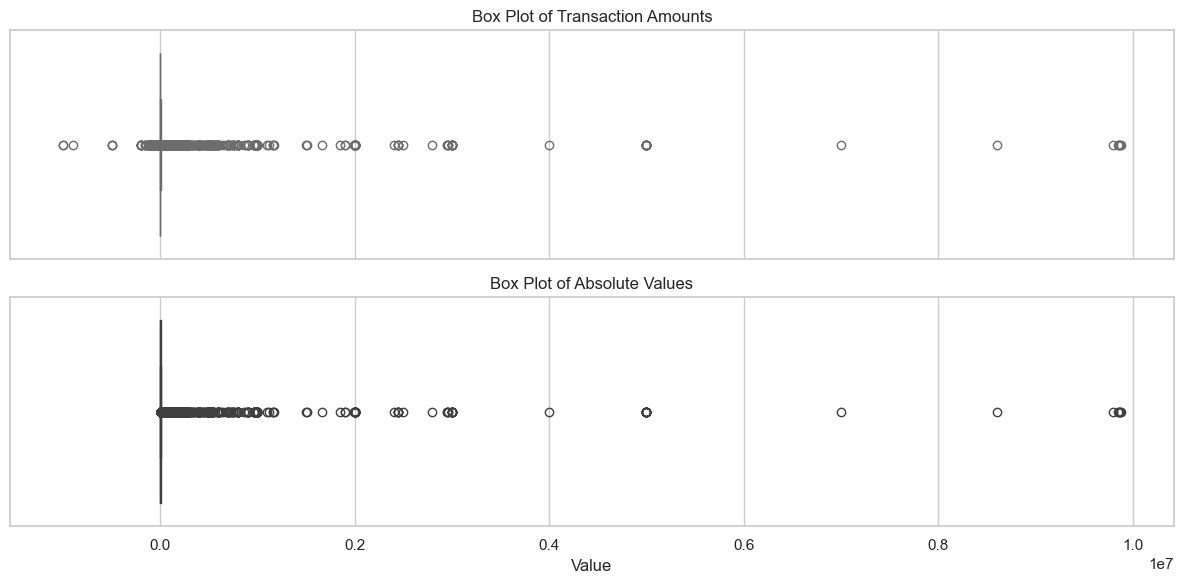

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

sns.boxplot(x=df['Amount'], ax=axes[0], color='salmon')
axes[0].set_title('Box Plot of Transaction Amounts')

sns.boxplot(x=df['Value'], ax=axes[1], color='lightseagreen')
axes[1].set_title('Box Plot of Absolute Values')

plt.tight_layout()
plt.show()

### Top EDA Insights
1. **Extreme Data Skewness:** The distribution of `Amount` and `Value` is highly skewed with a massive range, showing that a small fraction of transactions contains massive transaction values. This means standard scaling won't be enough; we will benefit heavily from grouping these variables into bins using Weight of Evidence (WoE).
2. **Highly Concentrated Categories:** A few select values in `ProductCategory` and `ChannelId` represent the vast majority of platform traffic. This uneven distribution means we must ensure our RFM grouping contains a representative population sample.
3. **Clean Baseline Data:** There are zero null values present across the critical structural variables, indicating that the baseline dataset is uniform and our processing pipelines won't require immediate structural data imputation or row drops.